In [1]:
import numpy as np
import torch
from scipy import signal
import matplotlib.pyplot as plt
import torch.nn.functional as F

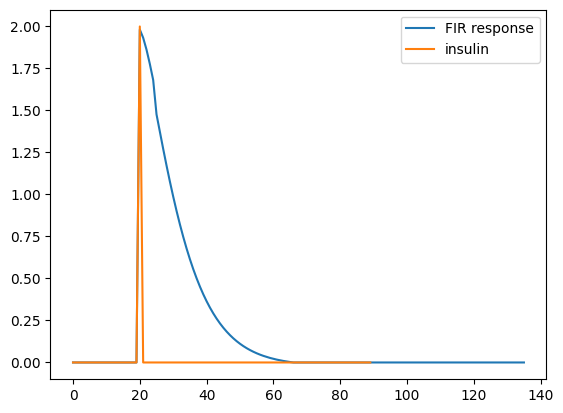

In [2]:




curves = torch.tensor([0.990779155337314,	0.966438249102907,	0.931195748571870,	0.888401018064230,	0.840694176359025,	0.738327753268755,	0.686479230690239,	0.635504299555202,	0.586070630621767,	0.538651500449868,	0.493566347259654,	0.451013824454206,	0.411098659690879,	0.373853406902100,	0.339255994601592,	0.307243820227643,	0.277725012193296,	0.250587374561936,	0.225705440349289,	0.202945985440546,	0.182172293550750,	0.163247411493730,	0.146036591540201,	0.130409082400233,	0.116239401155461,	0.103408194285511,	0.0918027759396487,	0.0813174150955827,	0.0718534296352993,	0.0633191341625401,	0.0556296791789179,	0.0487068116845709,	0.0424785810902314,	0.0368790092838137,	0.0318477395889466,	0.0273296760211935,	0.0232746215538583,	0.0196369219358883,	0.0163751198657132,	0.0134516229389668,	0.0108323876905139,	0.00848662118876831,	0.00638650096897375,	0.00450691357556776,	0.00282521159217597,	0.00132098874658693,	-2.41275328505264e-05])



y_ref = torch.cat([
    -torch.zeros(20),
    torch.sin(torch.linspace(0, torch.pi, 50)),
    -torch.zeros(20)
])

u = torch.cat([
    torch.zeros(20),
    torch.tensor([2.0]),
    torch.zeros(69)
])

# reshape (T, dim_in)
u = u[:, None].float()        # (T, 1)
y_ref = y_ref[:, None].float()  # (T, 1)


IOB_torch = torch.tensor(signal.convolve(u[:, 0].numpy(), curves.numpy(), mode='full'))

plt.figure()
plt.plot(IOB_torch.numpy(), label='FIR response')
# plt.plot(y_ref.numpy(), label='y_ref')
plt.plot(u.numpy(), label='insulin')
plt.legend()
plt.show()

Testing moving_average_online...


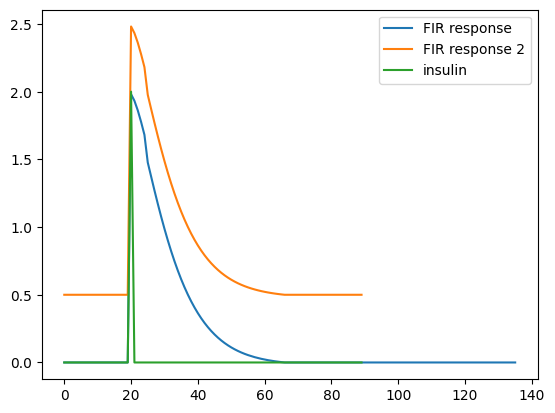

In [15]:

def moving_average_online(x, window_size, weights_mode='uniform', custom_weights=None):
    """
    Weighted moving average causale (online).
    
    Args:
        x: [batch, time, features]
        window_size: dimensione della finestra
        weights_mode: 'uniform' o 'custom'
        custom_weights: tensore di pesi se weights_mode='custom' [window_size]
    
    Returns:
        [batch, time, features]
    """
    # x: [batch, time, features]
    batch, time, features = x.shape
    device = x.device
    
    if weights_mode == 'uniform':
        weights = torch.ones(window_size, device=device) / window_size
    elif weights_mode == 'custom':
        if custom_weights is None:
            raise ValueError("custom_weights deve essere fornito quando weights_mode='custom'")
        weights = custom_weights.to(device)
        if weights.shape[0] != window_size:
            raise ValueError(f"custom_weights deve avere lunghezza {window_size}")
        weights = weights  # Normalizza
    else:
        raise ValueError(f"weights_mode '{weights_mode}' non riconosciuto")
    
    # Prendi il primo elemento temporale
    first_element = x[:, 0:1, :]  # [batch, 1, features]
    
    # Ripetilo window_size - 1 volte
    padding = first_element.repeat(1, window_size - 1, 1)  # [batch, window_size-1, features]
    
    # Concatena il padding con l'input originale
    x_padded = torch.cat([padding, x], dim=1)  # [batch, time + window_size - 1, features]
    
    # Permuta per convoluzione
    x_padded = x_padded.permute(0, 2, 1)  # [batch, features, time + window_size - 1]
    
    # Crea il kernel di convoluzione
    # weights: [window_size] -> [1, 1, window_size] per conv1d
    kernel = weights.view(1, 1, window_size)
    
    # Replica il kernel per ogni feature
    kernel = kernel.repeat(features, 1, 1)  # [features, 1, window_size]
    
    # Applica convoluzione (groups=features per mantenere le features separate)
    result = F.conv1d(x_padded, kernel, groups=features, stride=1)
    
    return result.permute(0, 2, 1)  # [batch, time, features]



print("Testing moving_average_online...")
IOB_torch_2 = moving_average_online(u[None,:,:], window_size=curves.shape[0], weights_mode='custom', custom_weights=torch.flip(curves, dims=[0]))

plt.figure()
plt.plot(IOB_torch.numpy(), label='FIR response')
plt.plot(IOB_torch_2[0,:,0].numpy()+0.5, label='FIR response 2')

# plt.plot(y_ref.numpy(), label='y_ref')
plt.plot(u.numpy(), label='insulin')
plt.legend()
plt.show()


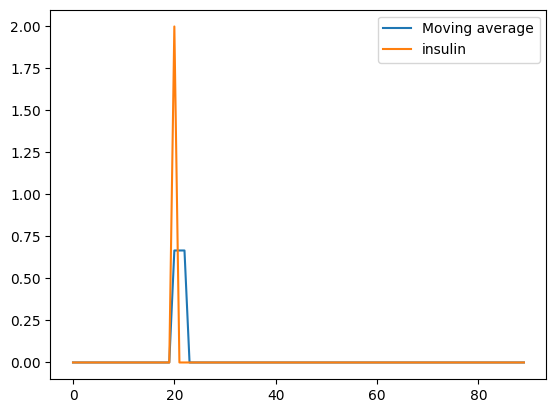

In [16]:
u_ma = moving_average_online(u[None,:,:], window_size=3, weights_mode='uniform')

plt.figure()

plt.plot(u_ma[0,:,0].numpy(), label='Moving average')

# plt.plot(y_ref.numpy(), label='y_ref')
plt.plot(u.numpy(), label='insulin')
plt.legend()
plt.show()